# 03 Model Training

## Purpose
Train a multiclass event-outcome model for batted-ball events and score event-level outcome probabilities for downstream xwOBA calculation.

## Inputs
- `data/processed/bbe_model_input.parquet`

## Outputs
- `artifacts/ground_ball_model.joblib`
- `artifacts/xwoba_bbe_model.joblib`
- `artifacts/outcome_label_encoder.joblib`
- `artifacts/model_features.joblib`
- `data/scored/bbe_scored.parquet`

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, log_loss, accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
SEED = 5

In [2]:
df = pd.read_parquet("data/processed/bbe_model_input.parquet")

print("Prepared dataset shape:", df.shape)
df.head()

Prepared dataset shape: (361509, 22)


,bbe_id,game_date,season,batter_id,batter_name,pitcher,events,outcome_label,launch_speed,launch_angle,sprint_speed,stand,p_throws,balls,strikes,pitch_type,zone,bb_type,hc_x,hc_y,home_team,away_team
0,716367_73_6_677008_687798,2023-10-01,2023,677008,"Robertson, Nick",687798,field_out,OUT,96.4,-17,27.4,L,R,2,2,CH,9,ground_ball,158.28,166.83,BAL,BOS
1,716367_71_5_663624_687798,2023-10-01,2023,663624,"Robertson, Nick",687798,field_out,OUT,68.3,46,28.2,R,R,3,1,FF,13,popup,168.39,135.05,BAL,BOS
2,716367_69_4_624512_608344,2023-10-01,2023,624512,"Irvin, Cole",608344,field_out,OUT,62.6,-64,25.9,L,L,0,2,FC,13,ground_ball,127.46,186.95,BAL,BOS
3,716367_68_3_622569_608344,2023-10-01,2023,622569,"Irvin, Cole",608344,field_out,OUT,80.5,-38,27.9,R,L,0,2,SI,1,ground_ball,153.72,172.92,BAL,BOS
4,716367_67_3_623993_670167,2023-10-01,2023,623993,"Schreiber, John",670167,field_out,OUT,82.0,43,26.7,L,R,2,0,ST,5,fly_ball,59.68,124.3,BAL,BOS


## Train ground ball classifier

In [3]:
gb_df = df[["launch_speed","launch_angle","bb_type","season"]].dropna().copy()
gb_df["is_gb"] = (gb_df["bb_type"] == "ground_ball").astype(int)
train_gb = gb_df[gb_df["season"] < 2025].copy()
X_gb = train_gb[["launch_speed","launch_angle"]].astype(float)
y_gb = train_gb["is_gb"].astype(int)

gb_model = LogisticRegression(
    max_iter=2000,
    random_state=SEED
)

gb_model.fit(X_gb, y_gb)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",5
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

## Create sprint effect feature

In [4]:
df["gb_prob"] = np.nan
df["ground_ball"] = 0
df["sprint_effect"] = 0.0
gb_score_mask = df[["launch_speed", "launch_angle"]].notna().all(axis=1)
df.loc[gb_score_mask, "gb_prob"] = gb_model.predict_proba(
    df.loc[gb_score_mask, ["launch_speed", "launch_angle"]].astype(float)
)[:, 1]
df.loc[gb_score_mask, "ground_ball"] = (
    df.loc[gb_score_mask, "gb_prob"] > 0.70
).astype(int)
df["sprint_effect"] = df["sprint_speed"] * df["ground_ball"]

df.head()

,bbe_id,game_date,season,batter_id,batter_name,pitcher,events,outcome_label,launch_speed,launch_angle,sprint_speed,stand,p_throws,balls,strikes,pitch_type,zone,bb_type,hc_x,hc_y,home_team,away_team,gb_prob,ground_ball,sprint_effect
0,716367_73_6_677008_687798,2023-10-01,2023,677008,"Robertson, Nick",687798,field_out,OUT,96.4,-17,27.4,L,R,2,2,CH,9,ground_ball,158.28,166.83,BAL,BOS,9.999998e-01,1,27.4
1,716367_71_5_663624_687798,2023-10-01,2023,663624,"Robertson, Nick",687798,field_out,OUT,68.3,46,28.2,R,R,3,1,FF,13,popup,168.39,135.05,BAL,BOS,2.282690e-09,0,0.0
2,716367_69_4_624512_608344,2023-10-01,2023,624512,"Irvin, Cole",608344,field_out,OUT,62.6,-64,25.9,L,L,0,2,FC,13,ground_ball,127.46,186.95,BAL,BOS,1.000000e+00,1,25.9
3,716367_68_3_622569_608344,2023-10-01,2023,622569,"Irvin, Cole",608344,field_out,OUT,80.5,-38,27.9,R,L,0,2,SI,1,ground_ball,153.72,172.92,BAL,BOS,1.000000e+00,1,27.9
4,716367_67_3_623993_670167,2023-10-01,2023,623993,"Schreiber, John",670167,field_out,OUT,82.0,43,26.7,L,R,2,0,ST,5,fly_ball,59.68,124.3,BAL,BOS,2.142430e-09,0,0.0


## Define target and model features

In [5]:
TARGET = "outcome_label"
FEATURES = [
    "launch_speed",
    "launch_angle",
    "sprint_effect"
]
MODEL_VERSION = "xwoba_xgb_v1"
train_df = df.dropna(subset=FEATURES + [TARGET]).copy()

print("Training rows:", train_df.shape[0])
print("Target distribution:")
print(train_df[TARGET].value_counts())

Training rows: 361509
Target distribution:
outcome_label
OUT    240994
1B      77802
2B      23721
HR      16959
3B       2033
Name: count, dtype: int64


## Separate predictors and target

In [6]:
X = train_df[FEATURES].astype(float).copy()
y = train_df[TARGET].copy()
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['1B' '2B' '3B' 'HR' 'OUT']


## Train / validation split

In [7]:
train_mask = train_df["season"] != 2025
valid_mask = train_df["season"] == 2025

X_train = X.loc[train_mask].copy()
X_valid = X.loc[valid_mask].copy()

y_train = y_encoded[train_mask]
y_valid = y_encoded[valid_mask]

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

Train shape: (240722, 3)
Validation shape: (120787, 3)


## Train multiclass XGBoost model

In [8]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    eval_metric="mlogloss",
    tree_method="hist"
)

model.fit(X_train, y_train)

print("Model trained.")

Model trained.


## Evaluate validation performance

In [9]:
y_valid_pred = model.predict(X_valid)
y_valid_proba = model.predict_proba(X_valid)

print("Accuracy:", round(accuracy_score(y_valid, y_valid_pred), 4))
print("Log loss:", round(log_loss(y_valid, y_valid_proba), 4))
print()

print(
    classification_report(
        y_valid,
        y_valid_pred,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.7682
Log loss: 0.5692

              precision    recall  f1-score   support

          1B       0.64      0.57      0.60     26039
          2B       0.41      0.15      0.22      7732
          3B       0.00      0.00      0.00       627
          HR       0.68      0.73      0.70      5645
         OUT       0.82      0.90      0.86     80744

    accuracy                           0.77    120787
   macro avg       0.51      0.47      0.48    120787
weighted avg       0.74      0.77      0.75    120787



In [10]:
from sklearn.metrics import log_loss
from sklearn.preprocessing import label_binarize

# y_valid is already encoded
y_valid_encoded = np.array(y_valid)

# Validation probabilities
valid_probs = model.predict_proba(X_valid)

# Log loss
valid_logloss = log_loss(y_valid_encoded, valid_probs)
print(f"Validation Log Loss: {valid_logloss:.5f}")

# Brier scores by class
y_valid_bin = label_binarize(
    y_valid_encoded,
    classes=np.arange(len(label_encoder.classes_))
)

print("\nBrier Score by Class:")
for i, cls in enumerate(label_encoder.classes_):
    brier = np.mean((valid_probs[:, i] - y_valid_bin[:, i]) ** 2)
    print(f"  {cls}: {brier:.5f}")

# Reliability table helper
def reliability_table(y_true_binary, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []

    for b in range(n_bins):
        if b < n_bins - 1:
            mask = (y_prob >= bins[b]) & (y_prob < bins[b + 1])
        else:
            mask = (y_prob >= bins[b]) & (y_prob <= bins[b + 1])

        if mask.sum() == 0:
            continue

        rows.append({
            "bin_range": f"{bins[b]:.1f}-{bins[b+1]:.1f}",
            "count": int(mask.sum()),
            "avg_pred_prob": float(y_prob[mask].mean()),
            "observed_rate": float(y_true_binary[mask].mean()),
            "gap": float(y_prob[mask].mean() - y_true_binary[mask].mean())
        })

    return pd.DataFrame(rows)

for i, cls in enumerate(label_encoder.classes_):
    print(f"\nCalibration table for class: {cls}")
    y_true_binary = (y_valid_encoded == i).astype(int)
    display(reliability_table(y_true_binary, valid_probs[:, i], n_bins=10))

Validation Log Loss: 0.56921

Brier Score by Class:
  1B: 0.10924
  2B: 0.05176
  3B: 0.00512
  HR: 0.01965
  OUT: 0.13436

Calibration table for class: 1B


,bin_range,count,avg_pred_prob,observed_rate,gap
0,0.0-0.1,58901,0.024731,0.024991,-0.000260
1,0.1-0.2,15402,0.146376,0.151863,-0.005487
2,0.2-0.3,10451,0.246200,0.251268,-0.005068
3,0.3-0.4,8147,0.350473,0.349699,0.000774
4,0.4-0.5,7526,0.448814,0.433829,0.014985
5,0.5-0.6,8022,0.549488,0.530042,0.019446
6,0.6-0.7,5019,0.646490,0.648336,-0.001846
7,0.7-0.8,3892,0.751794,0.753854,-0.002060
8,0.8-0.9,2691,0.841559,0.874768,-0.033209
9,0.9-1.0,736,0.920141,0.942935,-0.022794



Calibration table for class: 2B


,bin_range,count,avg_pred_prob,observed_rate,gap
0,0.0-0.1,96923,0.027317,0.026650,0.000667
1,0.1-0.2,11768,0.139577,0.133243,0.006334
2,0.2-0.3,6014,0.246660,0.223977,0.022682
3,0.3-0.4,3314,0.344642,0.323174,0.021467
4,0.4-0.5,2056,0.447312,0.395914,0.051397
5,0.5-0.6,711,0.530726,0.490858,0.039868
6,0.6-0.7,1,0.684449,0.000000,0.684449



Calibration table for class: 3B


,bin_range,count,avg_pred_prob,observed_rate,gap
0,0.0-0.1,120783,0.005957,0.005191,0.000766
1,0.1-0.2,4,0.121399,0.000000,0.121399



Calibration table for class: HR


,bin_range,count,avg_pred_prob,observed_rate,gap
0,0.0-0.1,108697,0.003045,0.002640,0.000405
1,0.1-0.2,2548,0.148501,0.133438,0.015063
2,0.2-0.3,1818,0.245080,0.212871,0.032208
3,0.3-0.4,1298,0.345855,0.298921,0.046934
4,0.4-0.5,1220,0.450924,0.411475,0.039449
5,0.5-0.6,922,0.551989,0.503254,0.048735
6,0.6-0.7,917,0.655622,0.570338,0.085284
7,0.7-0.8,1006,0.749704,0.666998,0.082706
8,0.8-0.9,985,0.854835,0.805076,0.049759
9,0.9-1.0,1376,0.953009,0.937500,0.015509



Calibration table for class: OUT


,bin_range,count,avg_pred_prob,observed_rate,gap
0,0.0-0.1,8753,0.061684,0.052096,0.009588
1,0.1-0.2,5610,0.145954,0.165597,-0.019644
2,0.2-0.3,5345,0.251314,0.284565,-0.033251
3,0.3-0.4,8155,0.349866,0.384549,-0.034683
4,0.4-0.5,8281,0.449664,0.474218,-0.024555
5,0.5-0.6,9172,0.549088,0.571086,-0.021998
6,0.6-0.7,9356,0.651539,0.667165,-0.015626
7,0.7-0.8,12160,0.751906,0.753947,-0.002042
8,0.8-0.9,16998,0.852918,0.852865,0.000053
9,0.9-1.0,36957,0.963065,0.964093,-0.001028


## Plot multiclass confusion matrix

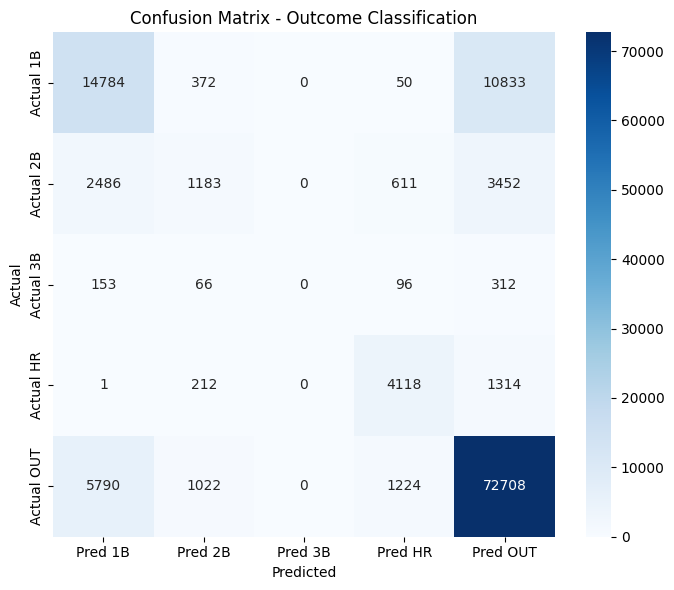

In [11]:
cm = confusion_matrix(y_valid, y_valid_pred)
plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f"Pred {cls}" for cls in label_encoder.classes_],
    yticklabels=[f"Actual {cls}" for cls in label_encoder.classes_]
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Outcome Classification')
plt.tight_layout()
plt.show()

## Plot hit versus out confusion matrix

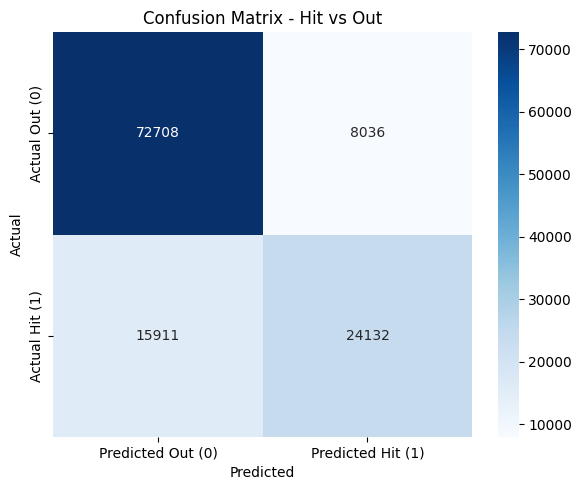

In [12]:
y_valid_binary = (label_encoder.inverse_transform(y_valid) != "OUT").astype(int)
y_pred_binary = (label_encoder.inverse_transform(y_valid_pred) != "OUT").astype(int)
cm = confusion_matrix(y_valid_binary, y_pred_binary)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Out (0)', 'Predicted Hit (1)'],
    yticklabels=['Actual Out (0)', 'Actual Hit (1)']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Hit vs Out')
plt.tight_layout()
plt.show()

## Fit final model on all prepared rows

In [13]:
final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    eval_metric="mlogloss",
    tree_method="hist"
)

final_model.fit(X, y_encoded)

print("Final model fit on all prepared rows.")

Final model fit on all prepared rows.


## Score all batted-ball events

In [14]:
score_df = df.copy()
score_mask = score_df[FEATURES].notna().all(axis=1)
all_probs = final_model.predict_proba(
    score_df.loc[score_mask, FEATURES].astype(float)
)
predicted_labels = label_encoder.inverse_transform(
    np.argmax(all_probs, axis=1)
)
score_df["predicted_outcome"] = np.nan
score_df.loc[score_mask, "predicted_outcome"] = predicted_labels

print("Rows scored:", int(score_mask.sum()))
print("Rows not scored:", int((~score_mask).sum()))

Rows scored: 361509
Rows not scored: 0


## Attach predicted probabilities

In [15]:
prob_cols = [f"prob_{cls}" for cls in label_encoder.classes_]
for col in prob_cols:
    score_df[col] = np.nan
score_df.loc[score_mask, prob_cols] = all_probs

print("Output shape:", score_df.shape)
print("Missing predictions:", score_df["predicted_outcome"].isna().sum())
print()
score_df.head()

Output shape: (361509, 31)
Missing predictions: 0



,bbe_id,game_date,season,batter_id,batter_name,pitcher,events,outcome_label,launch_speed,launch_angle,sprint_speed,stand,p_throws,balls,strikes,pitch_type,zone,bb_type,hc_x,hc_y,home_team,away_team,gb_prob,ground_ball,sprint_effect,predicted_outcome,prob_1B,prob_2B,prob_3B,prob_HR,prob_OUT
0,716367_73_6_677008_687798,2023-10-01,2023,677008,"Robertson, Nick",687798,field_out,OUT,96.4,-17,27.4,L,R,2,2,CH,9,ground_ball,158.28,166.83,BAL,BOS,9.999998e-01,1,27.4,OUT,0.162701,0.010784,0.000255,1.331716e-06,0.826259
1,716367_71_5_663624_687798,2023-10-01,2023,663624,"Robertson, Nick",687798,field_out,OUT,68.3,46,28.2,R,R,3,1,FF,13,popup,168.39,135.05,BAL,BOS,2.282690e-09,0,0.0,OUT,0.214262,0.060130,0.000059,7.378736e-06,0.725542
2,716367_69_4_624512_608344,2023-10-01,2023,624512,"Irvin, Cole",608344,field_out,OUT,62.6,-64,25.9,L,L,0,2,FC,13,ground_ball,127.46,186.95,BAL,BOS,1.000000e+00,1,25.9,OUT,0.240705,0.000127,0.000005,2.667381e-07,0.759164
3,716367_68_3_622569_608344,2023-10-01,2023,622569,"Irvin, Cole",608344,field_out,OUT,80.5,-38,27.9,R,L,0,2,SI,1,ground_ball,153.72,172.92,BAL,BOS,1.000000e+00,1,27.9,OUT,0.058940,0.000652,0.000015,1.948217e-07,0.940393
4,716367_67_3_623993_670167,2023-10-01,2023,623993,"Schreiber, John",670167,field_out,OUT,82.0,43,26.7,L,R,2,0,ST,5,fly_ball,59.68,124.3,BAL,BOS,2.142430e-09,0,0.0,OUT,0.005989,0.006233,0.000406,3.701069e-06,0.987368


## Save scored dataset

In [16]:
os.makedirs("data/scored", exist_ok=True)

score_df.to_parquet("data/scored/bbe_scored.parquet", index=False)

print("Saved scored dataset to data/scored/bbe_scored.parquet")

Saved scored dataset to data/scored/bbe_scored.parquet


## Save model artifacts

In [17]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(gb_model, "artifacts/ground_ball_model.joblib")
joblib.dump(final_model, "artifacts/xwoba_bbe_model.joblib")
joblib.dump(label_encoder, "artifacts/outcome_label_encoder.joblib")
joblib.dump(FEATURES, "artifacts/model_features.joblib")

print("Saved model artifacts.")

Saved model artifacts.
